# NSL-KDD 数据探索 (EDA)

> M1 任务 1.8 - 基于 `src.data` 模块的基础 EDA
>
> **目标**: 验证数据加载/预处理管线可用，理解 NSL-KDD 数据分布

## 流程
1. 加载 KDDTrain+/KDDTest+
2. 数据形状与类型
3. 缺失值检查
4. 标签分布（二分类 + 多分类）
5. 攻击大类分布（DoS / Probe / R2L / U2R）
6. 数值特征基本统计


In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_train, load_test, FEATURE_NAMES, COLUMN_NAMES
from src.data.preprocessor import check_missing, make_labels

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


In [2]:
df_train = load_train()
df_test = load_test()

print(f"训练集 shape: {df_train.shape}")
print(f"测试集 shape: {df_test.shape}")
print(f"\n特征名（前 5）: {FEATURE_NAMES[:5]}")
print(f"列名总数: {len(COLUMN_NAMES)}（41 特征 + label + difficulty）")


训练集 shape: (125973, 43)
测试集 shape: (22544, 43)

特征名（前 5）: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes']
列名总数: 43（41 特征 + label + difficulty）


In [3]:
n_train, cols_train = check_missing(df_train)
n_test, cols_test = check_missing(df_test)
print(f"训练集缺失值: {n_train}")
print(f"测试集缺失值: {n_test}")


训练集缺失值: 0
测试集缺失值: 0


=== 二分类标签分布 ===

训练集:
label
normal     67343
anomaly    58630
Name: count, dtype: int64

测试集:
label
anomaly    12833
normal      9711
Name: count, dtype: int64


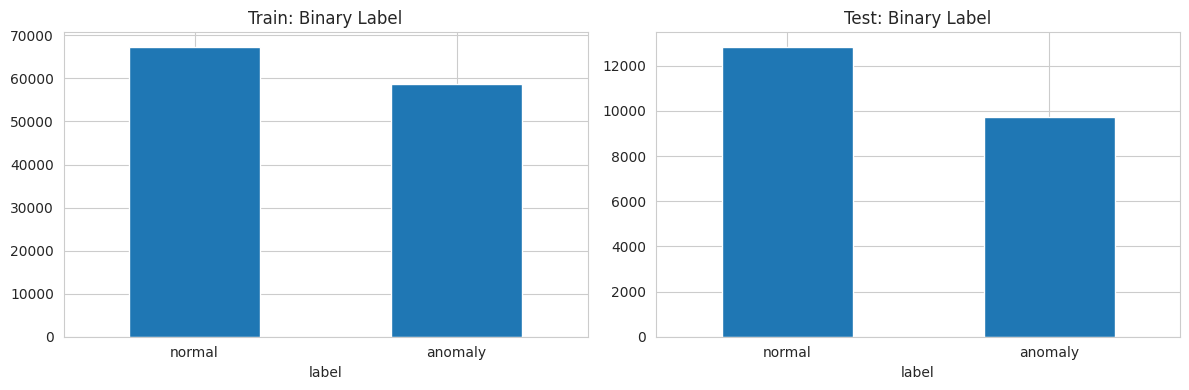

In [4]:
y_train_bin = make_labels(df_train['label'], task='binary')
y_test_bin = make_labels(df_test['label'], task='binary')

print("=== 二分类标签分布 ===")
print("\n训练集:")
print(y_train_bin.value_counts().rename({0: 'normal', 1: 'anomaly'}))
print("\n测试集:")
print(y_test_bin.value_counts().rename({0: 'normal', 1: 'anomaly'}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_train_bin.value_counts().plot(kind='bar', ax=axes[0], title='Train: Binary Label')
y_test_bin.value_counts().plot(kind='bar', ax=axes[1], title='Test: Binary Label')
axes[0].set_xticklabels(['normal', 'anomaly'], rotation=0)
axes[1].set_xticklabels(['normal', 'anomaly'], rotation=0)
plt.tight_layout()
plt.show()


=== 攻击大类分布 ===

训练集:
label
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

测试集:
label
Normal    9711
DoS       7460
R2L       2885
Probe     2421
U2R         67
Name: count, dtype: int64


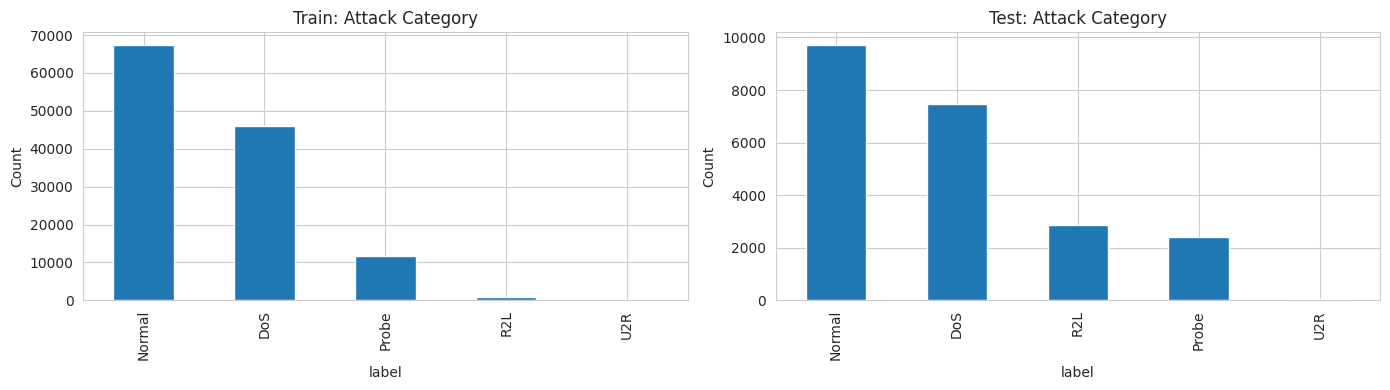

In [5]:
# NSL-KDD 攻击大类映射（论文标准）
ATTACK_CATEGORY = {
    'normal': 'Normal',
    # DoS
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS', 'apache2': 'DoS', 'udpstorm': 'DoS',
    'processtable': 'DoS', 'worm': 'DoS', 'mailbomb': 'DoS',
    # Probe
    'satan': 'Probe', 'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe',
    'mscan': 'Probe', 'saint': 'Probe',
    # R2L
    'guess_passwd': 'R2L', 'ftp_write': 'R2L', 'imap': 'R2L', 'phf': 'R2L',
    'multihop': 'R2L', 'warezmaster': 'R2L', 'warezclient': 'R2L', 'spy': 'R2L',
    'xlock': 'R2L', 'xsnoop': 'R2L', 'snmpguess': 'R2L', 'snmpgetattack': 'R2L',
    'httptunnel': 'R2L', 'sendmail': 'R2L', 'named': 'R2L',
    # U2R
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'rootkit': 'U2R', 'perl': 'U2R',
    'sqlattack': 'U2R', 'xterm': 'U2R', 'ps': 'U2R',
}

train_cats = df_train['label'].map(ATTACK_CATEGORY).fillna('Unknown')
test_cats = df_test['label'].map(ATTACK_CATEGORY).fillna('Unknown')

print("=== 攻击大类分布 ===")
print("\n训练集:")
print(train_cats.value_counts())
print("\n测试集:")
print(test_cats.value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train_cats.value_counts().plot(kind='bar', ax=axes[0], title='Train: Attack Category')
test_cats.value_counts().plot(kind='bar', ax=axes[1], title='Test: Attack Category')
axes[0].set_ylabel('Count')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()


In [6]:
from src.data.preprocessor import NUMERIC_COLUMNS

numeric_stats = df_train[NUMERIC_COLUMNS].describe().T[['mean', 'std', 'min', 'max']]
print(f"数值特征数: {len(NUMERIC_COLUMNS)}")
print("\n数值特征统计（前 10 列）:")
print(numeric_stats.head(10).round(2))


数值特征数: 38

数值特征统计（前 10 列）:
                       mean         std  min           max
duration             287.14     2604.52  0.0  4.290800e+04
src_bytes          45566.74  5870331.18  0.0  1.379964e+09
dst_bytes          19779.11  4021269.15  0.0  1.309937e+09
land                   0.00        0.01  0.0  1.000000e+00
wrong_fragment         0.02        0.25  0.0  3.000000e+00
urgent                 0.00        0.01  0.0  3.000000e+00
hot                    0.20        2.15  0.0  7.700000e+01
num_failed_logins      0.00        0.05  0.0  5.000000e+00
logged_in              0.40        0.49  0.0  1.000000e+00
num_compromised        0.28       23.94  0.0  7.479000e+03


## 总结

### M1 EDA 关键发现

1. **数据规模**: 训练集 125,973 条 / 测试集 22,544 条，与官方数据一致
2. **无缺失值**: NSL-KDD 官方数据完整，无 NaN
3. **类别分布**:
   - 训练集 normal/anomaly ≈ 1.15:1（轻度不均衡）
   - 测试集 normal/anomaly ≈ 0.76:1（攻击占比更高，验证泛化能力）
4. **攻击大类**: 4 大类（DoS/Probe/R2L/U2R）+ Normal，DoS 类攻击最常见
5. **特征统计**: 数值特征量级差异大（如 src_bytes 最大 1.3 亿），需标准化

### 下一步（M2）
- 特征工程（特征选择、特征重要性）
- 处理样本不均衡（SMOTE / class_weight）
- 生成预处理后的数据文件供 M3/M4 使用
